# Simplify complex data relationships


**The goal:** build a binomial logistic regression model and evaluate the model's performance.

### Imports and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


In [2]:
# Load the dataset

df = pd.read_csv('waze_dataset.csv')

### Explore Data with EDA

In [3]:
df.info(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


(None, (14999, 13))

In [4]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [8]:
# Remove useless column

df = df.drop(columns='ID', axis=1)

In [9]:
# Check balance in the output label

df['label'].value_counts()

retained    11763
churned      2536
Name: label, dtype: int64

In [10]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


In [22]:
# Drop rows with missing data
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14299 entries, 0 to 14998
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    14299 non-null  object 
 1   sessions                 14299 non-null  int64  
 2   drives                   14299 non-null  int64  
 3   total_sessions           14299 non-null  float64
 4   n_days_after_onboarding  14299 non-null  int64  
 5   total_navigations_fav1   14299 non-null  int64  
 6   total_navigations_fav2   14299 non-null  int64  
 7   driven_km_drives         14299 non-null  float64
 8   duration_minutes_drives  14299 non-null  float64
 9   activity_days            14299 non-null  int64  
 10  driving_days             14299 non-null  int64  
 11  device                   14299 non-null  object 
 12  km_per_driving_day       14299 non-null  float64
 13  professional_driver      14299 non-null  int64  
dtypes: float64(4), int64(8

### Some feature engineering

#### `km_per_driving_day`

In [12]:
# Average number of km per driving day
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

df['km_per_driving_day'].describe()

count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

In [14]:
# Hanfle infinite value -- infinite means that driving_days is zero so it also means zero km per zero driving days

df.loc[df['km_per_driving_day'] == np.inf, 'km_per_driving_day'] = 0 

df['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

#### **`professional_driver`**

Binary feature:
* **1** for users who had 60 or more drives and drove on 15+ days in the last month.
* **0** instead

In [16]:
df['professional_driver'] = 0
df.loc[(df['drives'] > 59) & (df['driving_days'] > 14), 'professional_driver'] = 1

0    12405
1     2594
Name: professional_driver, dtype: int64

In [18]:
# Value imbalance
print(df['professional_driver'].value_counts())

# Churn rate for professional and non-professional driver to understand if is going to be a good predictive feature or not
print(df.groupby('professional_driver')['label'].value_counts(normalize=True))

professional_driver  label   
0                    retained    0.801202
                     churned     0.198798
1                    retained    0.924437
                     churned     0.075563
Name: label, dtype: float64

#### Outliers for column of interest

In [24]:
# Outliers set to the upper threshold for the columns of interest

column_list = ['duration_minutes_drives', 'driven_km_drives', 'total_navigations_fav2', 'total_navigations_fav1', 'total_sessions', 'drives', 'sessions']
for column in column_list:
    Ulim = df[column].quantile(0.95)
    df.loc[df[column] > Ulim, column] = Ulim

#### Encode categorical variables

In [27]:
# Binary column for `label`
df['label2'] = 0
df.loc[df['label'] == 'churned', 'label2'] = 1

df.sample(10)

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day,professional_driver,label2
9479,retained,168,160,265.051617,994,46,55,2389.653525,716.957173,18,16,iPhone,149.353345,1,0
9236,retained,61,49,188.404496,527,5,38,6280.064215,203.640141,18,12,iPhone,523.338685,0,0
8621,retained,66,54,76.896186,924,206,0,2468.044722,2049.218173,1,0,iPhone,0.000000,0,0
4268,retained,89,72,136.899613,1205,16,0,4473.629715,1468.921023,24,15,Android,298.241981,1,0
766,retained,26,25,117.114784,2610,7,0,7659.102669,2112.352934,17,10,iPhone,765.910267,0,0
8648,retained,33,29,61.401343,3329,211,0,4554.697357,1371.927429,7,6,Android,759.116226,0,0
3057,churned,243,200,455.439492,355,0,120,5562.202041,2167.486429,4,2,iPhone,2781.101020,0,1
5644,retained,138,113,160.905220,755,135,65,2783.992685,1502.459206,7,3,Android,927.997562,0,0
6027,retained,63,51,75.671992,1971,35,0,8858.877645,782.386168,31,29,Android,305.478539,0,0
1999,retained,7,7,94.048159,3199,157,118,886.282197,553.650586,12,9,iPhone,98.475800,0,0


In [40]:
# Dummie variables

df['device2'] = 0
df.loc[df['device'] == 'iPhone', 'device2'] = 1

## Check assumption for the model

#### **Collinearity**
Check correlation between feature

In [28]:
# Correlation matrix
df.corr(method='pearson')

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,professional_driver,label2
sessions,1.000000,0.996942,0.597189,0.007101,0.001858,0.008536,0.002996,-0.004545,0.025113,0.020294,-0.011569,0.443654,0.034911
drives,0.996942,1.000000,0.595285,0.006940,0.001058,0.009505,0.003445,-0.003889,0.024357,0.019608,-0.010989,0.444425,0.035865
total_sessions,0.597189,0.595285,1.000000,0.006596,0.000187,0.010371,0.001016,-0.000338,0.015755,0.012953,-0.016167,0.254433,0.024568
n_days_after_onboarding,0.007101,0.006940,0.006596,1.000000,-0.002450,-0.004968,-0.004652,-0.010167,-0.009418,-0.007321,0.011764,0.003770,-0.129263
total_navigations_fav1,0.001858,0.001058,0.000187,-0.002450,1.000000,0.002866,-0.007368,0.005646,0.010902,0.010419,-0.000197,-0.000224,0.052322
total_navigations_fav2,0.008536,0.009505,0.010371,-0.004968,0.002866,1.000000,0.003559,-0.003009,-0.004425,0.002000,0.006751,0.007126,0.015032
driven_km_drives,0.002996,0.003445,0.001016,-0.004652,-0.007368,0.003559,1.000000,0.690515,-0.007441,-0.009549,0.344811,-0.000904,0.019767
duration_minutes_drives,-0.004545,-0.003889,-0.000338,-0.010167,0.005646,-0.003009,0.690515,1.000000,-0.007895,-0.009425,0.239627,-0.012128,0.040407
activity_days,0.025113,0.024357,0.015755,-0.009418,0.010902,-0.004425,-0.007441,-0.007895,1.000000,0.947687,-0.397433,0.453825,-0.303851
driving_days,0.020294,0.019608,0.012953,-0.007321,0.010419,0.002000,-0.009549,-0.009425,0.947687,1.000000,-0.407917,0.469776,-0.294259


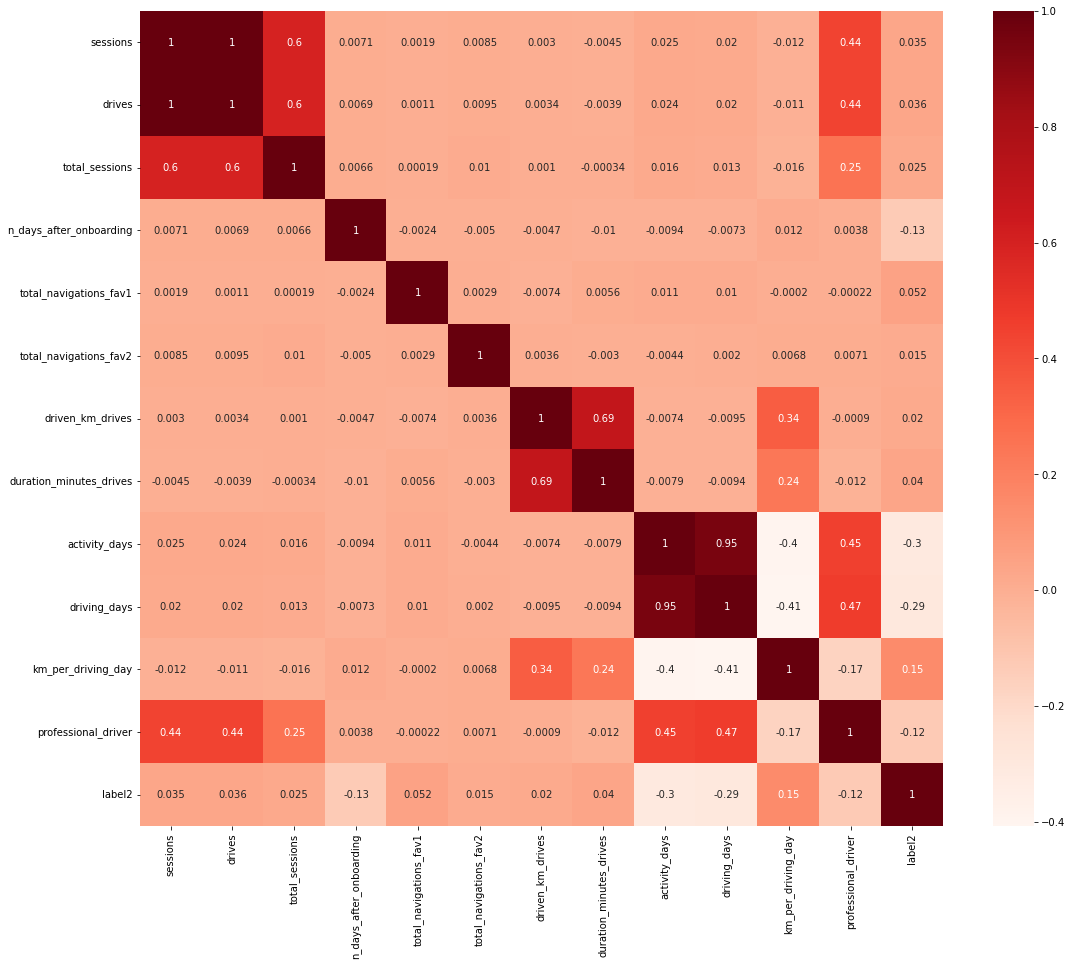

In [38]:
# Better visualization

plt.figure(figsize=(18,15))
sns.heatmap(df.corr(method='pearson'), annot = True, cmap='Reds')
plt.show()

**Absolute value of 0.7 or above**  means that these variable are strongly multicollinear. 
Therefore, only one of these variables should be used in your model.


### Model building**

In [41]:
# Isolate predictor variables

x = df.drop(columns=['label', 'label2', 'device', 'sessions', 'driving_days'], axis=1)

# Isolate target variable
y = df['label2']

x.head(10)

,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,professional_driver,device2
0,200,296.748273,2276,208,0,2628.845068,1985.775061,28,138.360267,1,0
1,107,326.896596,1225,19,64,8898.716275,3160.472914,13,1246.901868,0,1
2,95,135.522926,2651,0,0,3059.148818,1610.735904,14,382.393602,0,0
3,40,67.589221,15,322,7,913.591123,587.196542,7,304.530374,0,1
4,68,168.247020,1562,166,5,3950.202008,1219.555924,27,219.455667,1,0
5,103,279.544437,2637,0,0,901.238699,439.101397,15,81.930791,0,1
6,2,236.725314,360,185,18,5249.172828,726.577205,28,228.224906,0,1
7,35,176.072845,2999,0,0,7892.052468,2466.981741,22,394.602623,0,1
8,46,183.532018,424,0,26,2651.709764,1594.342984,25,132.585488,0,0
9,68,244.802115,2997,72,0,6043.460295,2341.838528,7,2014.486765,0,1


In [43]:
# train-test split

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify = y, random_state=42)

In [55]:
model = LogisticRegression(penalty = 'none',  max_iter=400) # predictor unscaled so penalty = none
model.fit(x_train, y_train) # fit

array([[ 1.91336945e-03,  3.27070888e-04, -4.06477637e-04,
         1.23175474e-03,  9.31478651e-04, -1.48604534e-05,
         1.09093436e-04, -1.06031965e-01,  1.82230940e-05,
        -1.52850416e-03, -1.04121752e-03]])

#### Model coefficient

In [54]:
pd.Series(model.coef_[0], index=x.columns)

drives                     0.001913
total_sessions             0.000327
n_days_after_onboarding   -0.000406
total_navigations_fav1     0.001232
total_navigations_fav2     0.000931
driven_km_drives          -0.000015
duration_minutes_drives    0.000109
activity_days             -0.106032
km_per_driving_day         0.000018
professional_driver       -0.001529
device2                   -0.001041
dtype: float64

In [56]:
model.intercept_

array([-0.00170675])

#### Check final assumption

Linear relationship between X and the estimated log odds (logit).

In [65]:
# Predicted probabilities of the training data

train_prob = model.predict_proba(x_train)  # 2-D array where each row represents a user in `X_train`. 
                                           # The first column is the probability of the user not churning
                                           # the second column is the probability of the user churning.

train_prob.shape, x_train.shape

((10724, 2), (10724, 11))

In [66]:
logit_data = x_train 

# logit column -- logit(p) = ln(\frac{p}{1-p})

logit_data['logit'] = [np.log(prob[0]/prob[1]) for prob in train_prob] 
logit_data.head()

,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,professional_driver,device2,logit
152,108,186.192746,3116,243,124,8898.716275,4668.180092,24,612.305861,1,1,2.745079
11899,2,3.487590,794,114,18,3286.545691,1780.902733,5,3286.545691,0,1,0.488161
10937,139,347.106403,331,4,7,7400.838975,2349.305267,15,616.736581,0,0,1.178243
669,108,455.439492,2320,11,4,6566.424830,4558.459870,18,410.401552,1,1,2.075803
8406,10,89.475821,2478,135,0,1271.248661,938.711572,27,74.779333,0,1,3.573298


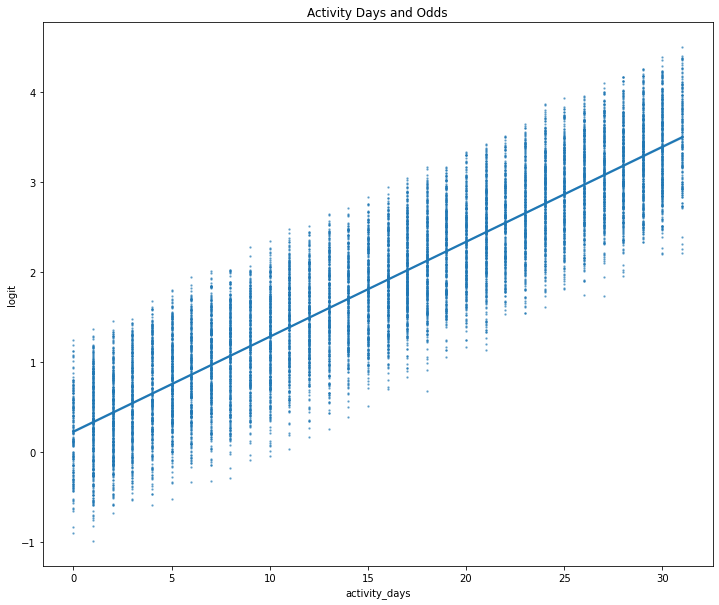

In [69]:
# Visualization

plt.figure(figsize=(12,10))
sns.regplot(data = logit_data, x = 'activity_days', y = 'logit', scatter_kws={'s': 2, 'alpha': 0.5})
plt.title('Activity Days and Odds')
plt.show()

### Results and evaluation

In [73]:
# Prediction on test data

y_pred = model.predict(x_test)

In [76]:
# Score the model
acc = accuracy_score(y_test, y_pred)
acc

0.8237762237762237

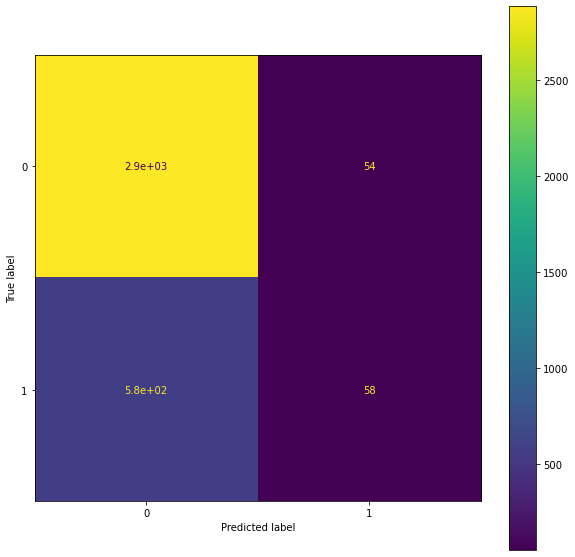

In [84]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels = model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = model.classes_ )

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax)
fig.show()


In [86]:
# Precision manually - just for fun
prec = 58/(58+54)
prec

0.5178571428571429

In [88]:
# Calculate recall manually  - just for fun
rec = 58/(58+580)
rec

0.09090909090909091

In [90]:
# Classification report
print(classification_report(y_test, y_pred, target_names=['retained', 'churned']))

              precision    recall  f1-score   support

    retained       0.83      0.98      0.90      2941
     churned       0.52      0.09      0.16       634

    accuracy                           0.82      3575
   macro avg       0.68      0.54      0.53      3575
weighted avg       0.78      0.82      0.77      3575



### Importance of the model's features

In [93]:
# Coefficient

importance = list(zip(x_train.columns, model.coef_[0])) 

# Sort it by coefficient value
importance = sorted(importance, key=lambda x: x[1], reverse=True)
importance

[('drives', 0.001913369447769776),
 ('total_navigations_fav1', 0.001231754741616306),
 ('total_navigations_fav2', 0.0009314786513814626),
 ('total_sessions', 0.00032707088819142904),
 ('duration_minutes_drives', 0.00010909343558951453),
 ('km_per_driving_day', 1.8223094015325207e-05),
 ('driven_km_drives', -1.4860453424647997e-05),
 ('n_days_after_onboarding', -0.00040647763730561445),
 ('device2', -0.0010412175209008018),
 ('professional_driver', -0.0015285041567402024),
 ('activity_days', -0.10603196504385491)]

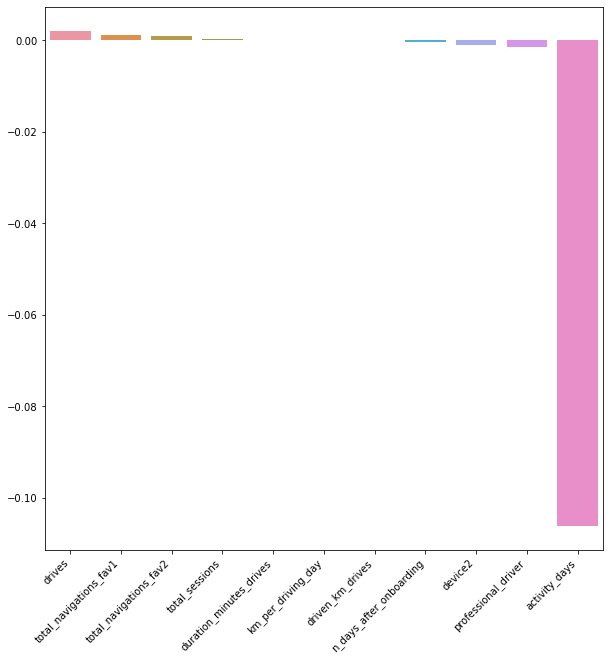

In [99]:
# Plot it

plt.figure(figsize=(10,10))
sns.barplot(x = [x[0] for x in importance], y = [x[1] for x in importance])
plt.title('Plot of importance')
plt.xticks(rotation=45, ha='right')
plt.show()